In [66]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [67]:
df = pd.read_csv("../../datasets/Liver_Patient_Dataset.csv", encoding='latin1')

# Clean column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')

In [68]:
df['Gender_of_the_patient'] = df['Gender_of_the_patient'].map({
    'Male': 1,
    'Female': 0
})

In [69]:
df.isnull().sum()

Age_of_the_patient                        2
Gender_of_the_patient                   902
Total_Bilirubin                         648
Direct_Bilirubin                        561
Alkphos_Alkaline_Phosphotase            796
Sgpt_Alamine_Aminotransferase           538
Sgot_Aspartate_Aminotransferase         462
Total_Protiens                          463
ALB_Albumin                             494
A/G_Ratio_Albumin_and_Globulin_Ratio    559
Result                                    0
dtype: int64

In [70]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [71]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)

In [72]:
X = df.drop(columns=['Result'])
y = df['Result']

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [74]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [75]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [76]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [77]:
svm = SVC(kernel='rbf', class_weight='balanced')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [78]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Results:")

    # Weighted metrics (for imbalance)
    precision_w = precision_score(y_test, y_pred, average='weighted')
    recall_w = recall_score(y_test, y_pred, average='weighted')
    f1_w = f1_score(y_test, y_pred, average='weighted')

    # Class-specific (Disease = class 2)
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=2)
    recall = recall_score(y_test, y_pred, pos_label=2)
    f1 = f1_score(y_test, y_pred, pos_label=2)

    print(f"Accuracy           : {acc:.4f}")
    print(f"Precision (class2) : {precision:.4f}")
    print(f"Recall (class2)    : {recall:.4f}")
    print(f"F1 Score (class2)  : {f1:.4f}")

    print("\nWeighted Metrics:")
    print(f"Precision (weighted): {precision_w:.4f}")
    print(f"Recall (weighted)   : {recall_w:.4f}")
    print(f"F1 Score (weighted) : {f1_w:.4f}")

    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [79]:
from IPython.display import display
display(df)

,Age_of_the_patient,Gender_of_the_patient,Total_Bilirubin,Direct_Bilirubin,Alkphos_Alkaline_Phosphotase,Sgpt_Alamine_Aminotransferase,Sgot_Aspartate_Aminotransferase,Total_Protiens,ALB_Albumin,A/G_Ratio_Albumin_and_Globulin_Ratio,Result
0,65.0,0.0,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,1.0,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,1.0,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,1.0,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,1.0,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
19078,58.0,1.0,2.9,1.3,482.0,22.0,34.0,7.0,2.4,0.50,1
19079,28.0,1.0,1.9,1.0,231.0,16.0,55.0,4.3,1.6,0.60,1
19080,50.0,1.0,2.2,1.0,610.0,17.0,28.0,7.3,2.6,0.55,1
19081,54.0,1.0,6.8,3.0,542.0,116.0,66.0,6.4,3.1,0.90,1


In [80]:
evaluate_model("Logistic Regression", y_test, y_pred_lr)




Logistic Regression Results:
Accuracy           : 0.6251
Precision (class2) : 0.4098
Recall (class2)    : 0.8631
F1 Score (class2)  : 0.5557

Weighted Metrics:
Precision (weighted): 0.7763
Recall (weighted)   : 0.6251
F1 Score (weighted) : 0.6431

Classification Report:
               precision    recall  f1-score   support

           1       0.91      0.54      0.68      2780
           2       0.41      0.86      0.56      1037

    accuracy                           0.63      3817
   macro avg       0.66      0.70      0.62      3817
weighted avg       0.78      0.63      0.64      3817


Confusion Matrix:
 [[1491 1289]
 [ 142  895]]


In [81]:

evaluate_model("Random Forest", y_test, y_pred_rf)


Random Forest Results:
Accuracy           : 0.9979
Precision (class2) : 0.9971
Recall (class2)    : 0.9952
F1 Score (class2)  : 0.9961

Weighted Metrics:
Precision (weighted): 0.9979
Recall (weighted)   : 0.9979
F1 Score (weighted) : 0.9979

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00      2780
           2       1.00      1.00      1.00      1037

    accuracy                           1.00      3817
   macro avg       1.00      1.00      1.00      3817
weighted avg       1.00      1.00      1.00      3817


Confusion Matrix:
 [[2777    3]
 [   5 1032]]


In [82]:
from sklearn.utils.validation import check_is_fitted

check_is_fitted(rf)   # should NOT raise error

In [83]:
import joblib

joblib.dump(rf, "../../models/liver_model.pkl")
print("Model saved successfully.")

Model saved successfully.


In [84]:
print(len(set(X_train.flatten()) & set(X_test.flatten())))

1028


In [85]:
evaluate_model("SVM", y_test, y_pred_svm)


SVM Results:
Accuracy           : 0.6586
Precision (class2) : 0.4398
Recall (class2)    : 0.9364
F1 Score (class2)  : 0.5985

Weighted Metrics:
Precision (weighted): 0.8179
Recall (weighted)   : 0.6586
F1 Score (weighted) : 0.6747

Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.56      0.70      2780
           2       0.44      0.94      0.60      1037

    accuracy                           0.66      3817
   macro avg       0.70      0.75      0.65      3817
weighted avg       0.82      0.66      0.67      3817


Confusion Matrix:
 [[1543 1237]
 [  66  971]]


In [86]:
import numpy as np

y_random = np.random.permutation(y_test)
accuracy_score(y_test, y_random)

0.5960178150379879

In [87]:
df.duplicated().sum()

np.int64(0)

In [88]:
train_df = pd.DataFrame(X_train)
test_df = pd.DataFrame(X_test)

duplicates = pd.merge(train_df, test_df, how='inner')
print(len(duplicates))

1


In [89]:
from sklearn.utils import shuffle

# Shuffle labels
y_shuffled = shuffle(y_train, random_state=42)

rf = RandomForestClassifier()
rf.fit(X_train, y_shuffled)

y_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Sanity Accuracy:", accuracy_score(y_test, y_pred))

Sanity Accuracy: 0.6209064710505633


In [90]:
import pandas as pd

importances = rf.feature_importances_
for col, val in zip(X.columns, importances):
    print(col, val)

Age_of_the_patient 0.5788243535225129
Gender_of_the_patient 0.054318434940381286
Total_Bilirubin 0.042600637335641366
Direct_Bilirubin 0.03273875967433511
Alkphos_Alkaline_Phosphotase 0.05763005287397047
Sgpt_Alamine_Aminotransferase 0.051894905229093215
Sgot_Aspartate_Aminotransferase 0.0543030845551672
Total_Protiens 0.047266709283551846
ALB_Albumin 0.04308787707244517
A/G_Ratio_Albumin_and_Globulin_Ratio 0.03733518551290133


In [91]:
df['Age_of_the_patient'].value_counts().head(10)

Age_of_the_patient
45.0    752
50.0    707
42.0    701
60.0    645
48.0    638
38.0    609
65.0    576
55.0    556
32.0    556
46.0    555
Name: count, dtype: int64

In [92]:
print(type(X_train))

<class 'numpy.ndarray'>


In [93]:
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X, y, cv=5)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Scores: [0.99607021 0.99842808 0.99423631 0.99606918 0.99816562]
Mean CV Accuracy: 0.9965938818339449


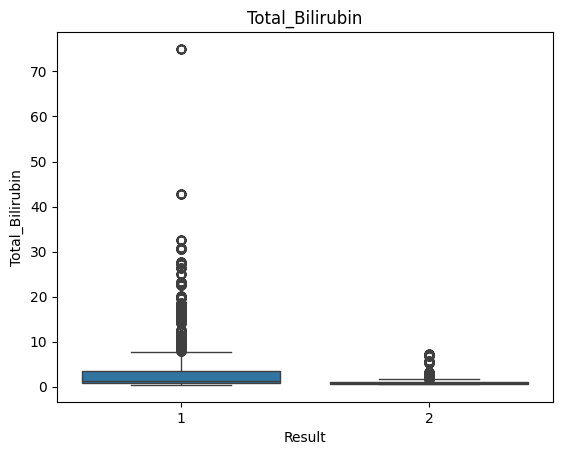

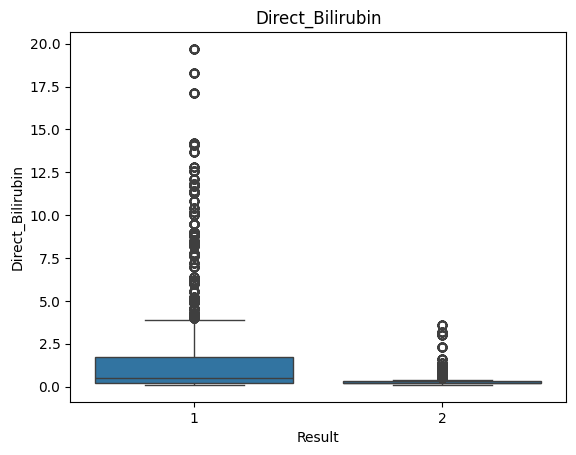

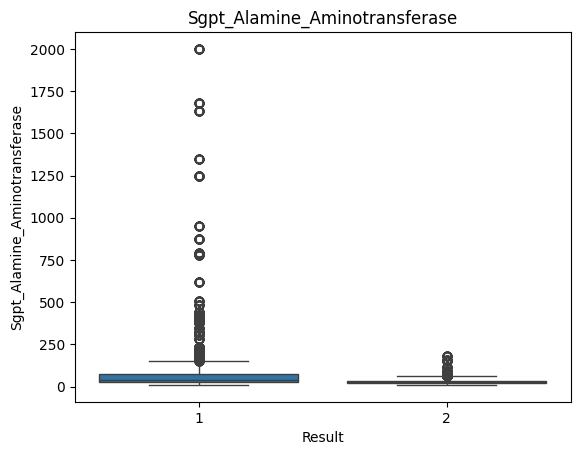

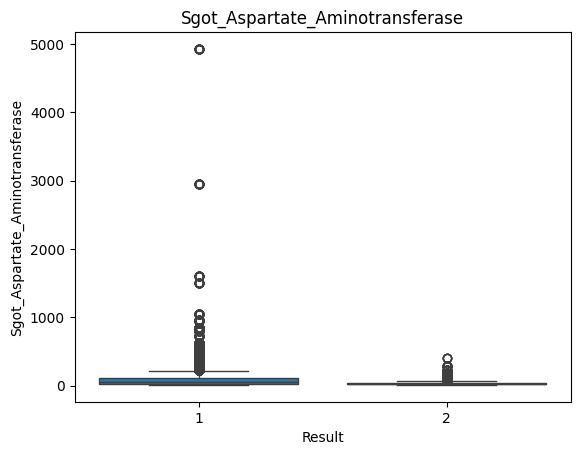

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    'Total_Bilirubin',
    'Direct_Bilirubin',
    'Sgpt_Alamine_Aminotransferase',
    'Sgot_Aspartate_Aminotransferase'
]

for col in features:
    sns.boxplot(x='Result', y=col, data=df)
    plt.title(col)
    plt.show()

In [95]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

print("Decision Tree Accuracy:", dt.score(X_test, y_test))

Decision Tree Accuracy: 0.7133874770762378


In [96]:
X_no_age = X.drop(columns=['Age_of_the_patient'])

from sklearn.model_selection import cross_val_score
rf = RandomForestClassifier(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_no_age, y, cv=5)

print("New CV Accuracy:", scores.mean())

New CV Accuracy: 0.9965938955648597
